Obtencion de los datos.

https://archive.ics.uci.edu/dataset/222/bank+marketing

https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip

Por un tema de comodidad, dejo disponible el csv sin modificar en el repositorio.

| Variable Name | Role | Type | Description | Units | Missing Values |
| :--- | :--- | :--- | :--- | :--- | :--- |
| age | Feature | Integer | Age | | no |
| job | Feature | Categorical | Occupation/type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown') | | no |
| marital | Feature | Categorical | Marital Status/marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed) | | no |
| education | Feature | Categorical | Education Level (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown') | | no |
| default | Feature | Binary | has credit in default? | | no |
| balance | Feature | Integer | average yearly balance | euros | no |
| housing | Feature | Binary | has housing loan? | | no |
| loan | Feature | Binary | has personal loan? | | no |
| contact | Feature | Categorical | contact communication type (categorical: 'cellular','telephone') | | yes |
| day_of_week | Feature | Date | last contact day of the week | | |
| month | Feature | Date | last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec') | | no |
| duration | Feature | Integer | last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model. | seconds | no |
| campaign | Feature | Integer | number of contacts performed during this campaign and for this client (numeric, includes last contact) | | no |
| pdays | Feature | Integer | number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted) | | yes |
| previous | Feature | Integer | number of contacts performed before this campaign and for this client | | no |
| poutcome | Feature | Categorical | outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success') | | yes |
| y | Target | Binary | has the client subscribed a term deposit? | | no |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Carga del dataset con el delimitador correcto detectado (;)
df = pd.read_csv('bank-full.csv', sep=';')

# EXPLORACIÓN ESTRUCTURAL
print("### Resumen de Estructura ###")
print(f"Instancias: {df.shape[0]} | Atributos: {df.shape[1]}")

display(df.info())

### Resumen de Estructura ###
Instancias: 45211 | Atributos: 17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


None

In [ ]:
display(df.head(20))

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


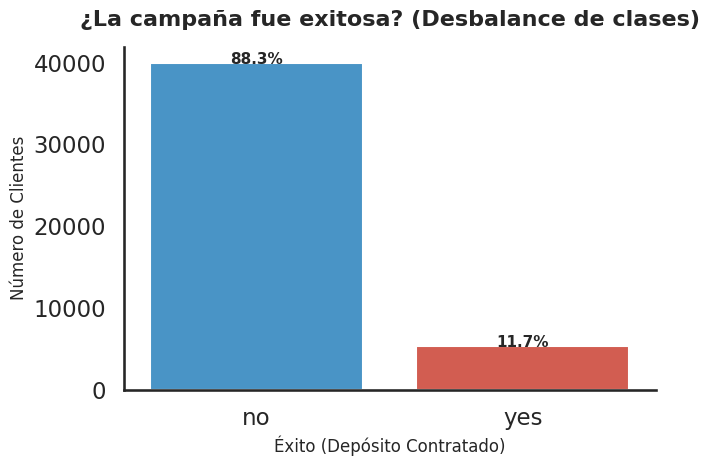

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para gráficos estilo presentación
sns.set_context("talk")
sns.set_style("white")

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='y', palette=['#3498db', '#e74c3c'])
plt.title("¿La campaña fue exitosa? (Desbalance de clases)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Éxito (Depósito Contratado)", fontsize=12)
plt.ylabel("Número de Clientes", fontsize=12)

# Añadir porcentajes sobre las barras
total = len(df['y'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x_pos = p.get_x() + p.get_width() / 2
    y_pos = p.get_height() + 500
    ax.annotate(percentage, (x_pos, y_pos), ha='center', va='center', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

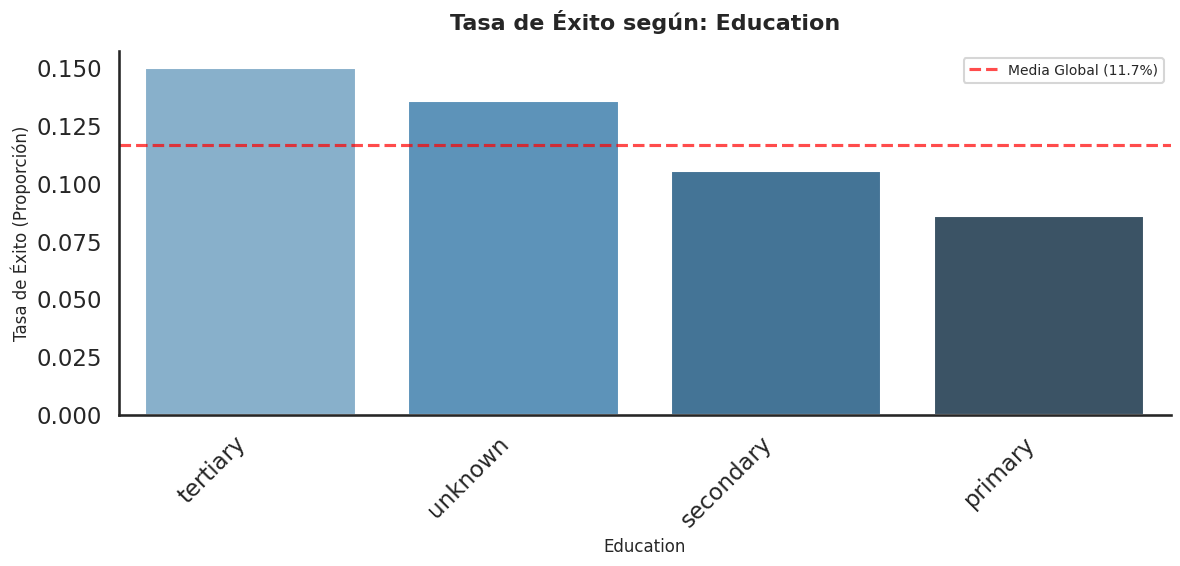

In [24]:
def plot_conversion_rate(dataframe, feature):
    # Calcular la tasa de conversión (éxitos / total de contactos)
    conversion = dataframe.groupby(feature)['y'].apply(lambda x: (x == 'yes').mean()).reset_index()
    conversion = conversion.sort_values(by='y', ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=conversion, x=feature, y='y', palette="Blues_d")
    
    # Línea de referencia con la tasa media global
    mean_rate = (dataframe['y'] == 'yes').mean()
    plt.axhline(mean_rate, color='red', linestyle='--', alpha=0.7, label=f'Media Global ({mean_rate:.1%})')
    
    plt.title(f"Tasa de Éxito según: {feature.capitalize()}", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel(feature.capitalize(), fontsize=12)
    plt.ylabel("Tasa de Éxito (Proporción)", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(fontsize=10)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# Ejemplo de uso con la columna 'education'
plot_conversion_rate(df, 'education')

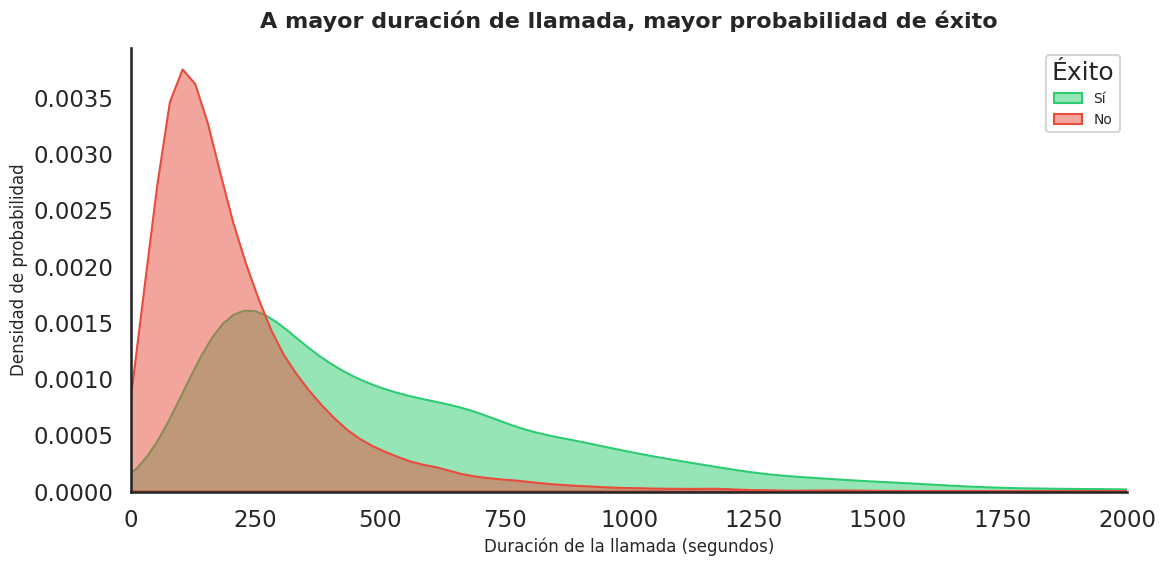

In [25]:
plt.figure(figsize=(12, 6))
# Usamos KDE plot acotado para ver la distribución de densidad
sns.kdeplot(data=df, x='duration', hue='y', fill=True, common_norm=False, palette=['#e74c3c', '#2ecc71'], alpha=0.5)

plt.title("A mayor duración de llamada, mayor probabilidad de éxito", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Duración de la llamada (segundos)", fontsize=12)
plt.ylabel("Densidad de probabilidad", fontsize=12)
plt.xlim(0, 2000) # Se acota el eje X para omitir outliers extremos y mejorar la lectura
plt.legend(title="Éxito", labels=['Sí', 'No'], fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

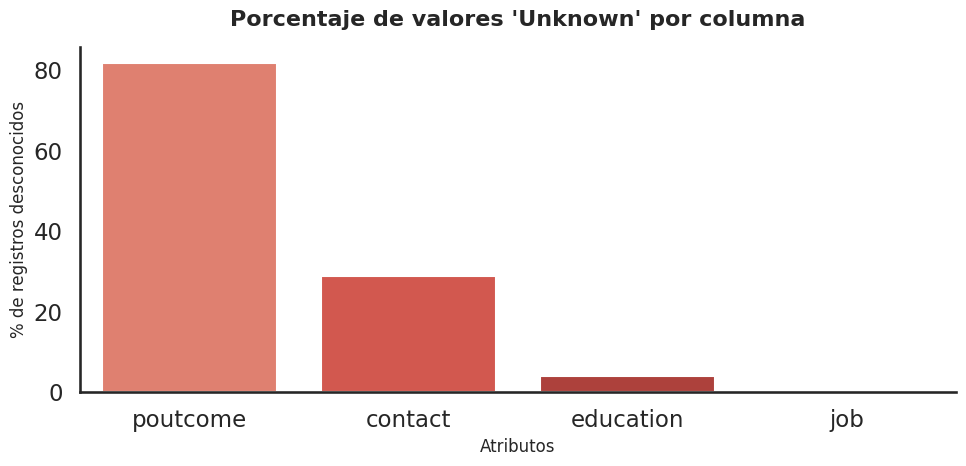

In [26]:
# Convertimos temporalmente 'unknown' a NaN para contarlos
df_with_nan = df.replace('unknown', np.nan)
unknown_counts = df_with_nan.isna().sum()
unknown_percentage = (unknown_counts / len(df)) * 100

# Filtrar solo las que tienen valores desconocidos
unknown_data = unknown_percentage[unknown_percentage > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=unknown_data.index, y=unknown_data.values, palette="Reds_d")
plt.title("Porcentaje de valores 'Unknown' por columna", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("% de registros desconocidos", fontsize=12)
plt.xlabel("Atributos", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

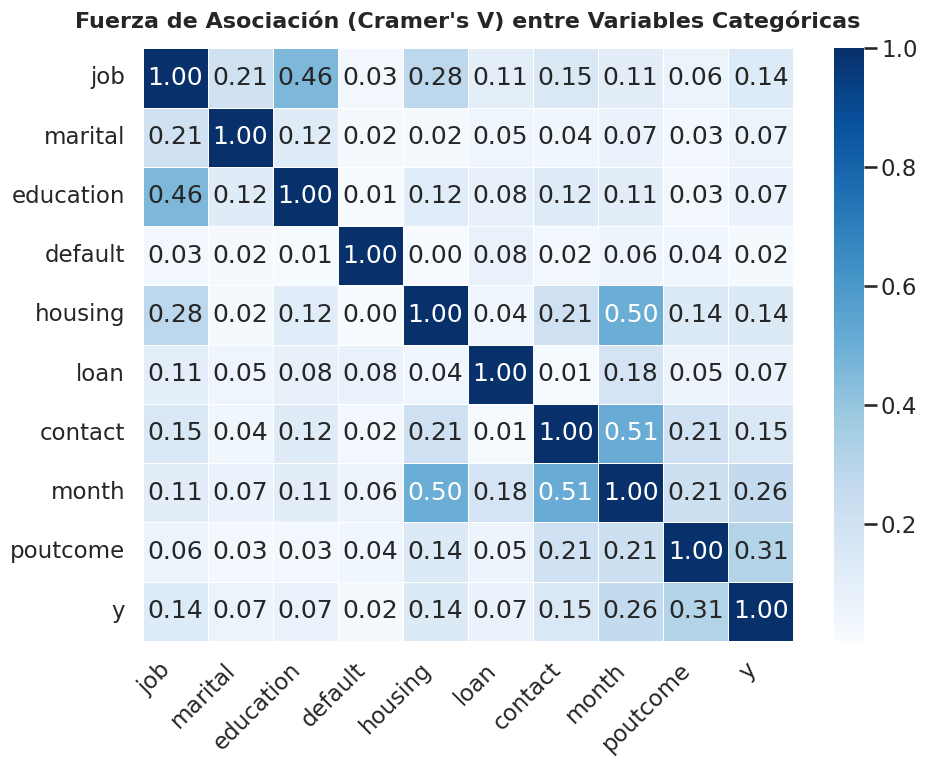

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calcula el coeficiente V de Cramer con corrección de sesgo."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # Corrección de bias para evitar sobreestimaciones en muestras pequeñas
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 1. Identificar columnas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns

# 2. Construir la matriz de Cramer's V
n_cols = len(categorical_cols)
cramers_matrix = pd.DataFrame(np.zeros((n_cols, n_cols)), 
                              columns=categorical_cols, 
                              index=categorical_cols)

for i in range(n_cols):
    for j in range(i, n_cols):
        col1 = categorical_cols[i]
        col2 = categorical_cols[j]
        if i == j:
            cramers_matrix.loc[col1, col2] = 1.0
        else:
            v = cramers_v(df[col1], df[col2])
            cramers_matrix.loc[col1, col2] = v
            cramers_matrix.loc[col2, col1] = v

# 3. Graficar un mapa de calor estilo presentación
plt.figure(figsize=(10, 8))
sns.set_context("talk")
sns.heatmap(cramers_matrix, annot=True, cmap="Blues", fmt=".2f", linewidths=.5)
plt.title("Fuerza de Asociación (Cramer's V) entre Variables Categóricas", fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
# ANÁLISIS DE CALIDAD DE DATOS (Data Cleaning Validation)

def data_quality_report(df):
    report = pd.DataFrame({
        'Tipo': df.dtypes,
        'Nulos': df.isnull().sum(),
        'Valores Únicos': df.nunique(),
        'Porcentaje Nulos': (df.isnull().sum() / len(df)) * 100
    })
    return report

display(data_quality_report(df))

,Tipo,Nulos,Valores Únicos,Porcentaje Nulos
age,int64,0,77,0.0
job,object,0,12,0.0
marital,object,0,3,0.0
education,object,0,4,0.0
default,object,0,2,0.0
balance,int64,0,7168,0.0
housing,object,0,2,0.0
loan,object,0,2,0.0
contact,object,0,3,0.0
day,int64,0,31,0.0


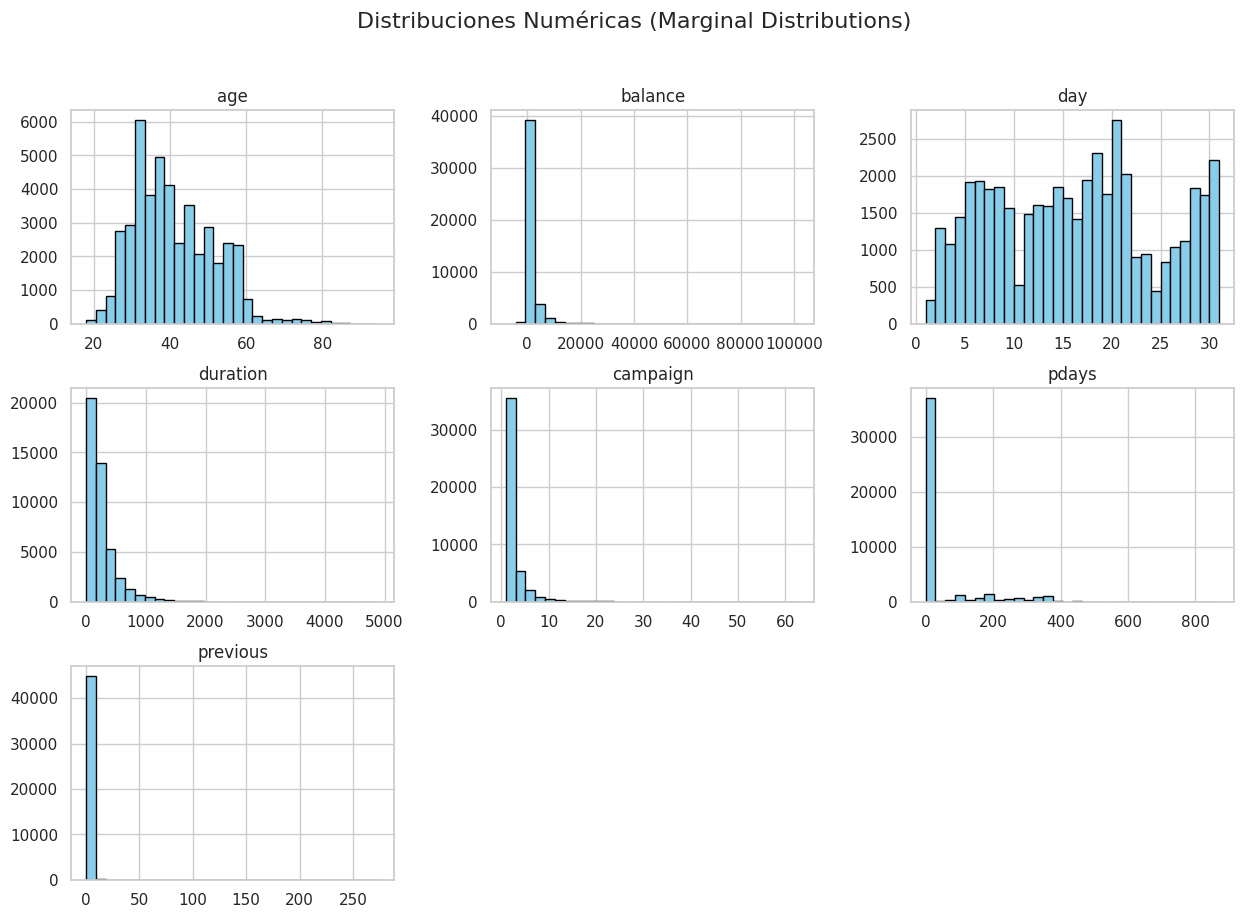

In [ ]:
# ANÁLISIS DE DISTRIBUCIONES (Clave para Datos Sintéticos)
# Separamos numéricas de categóricas
nums = df.select_dtypes(include=[np.number]).columns.tolist()
cats = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Visualización de variables numéricas
df[nums].hist(figsize=(15, 10), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Distribuciones Numéricas (Marginal Distributions)", fontsize=16)
plt.show()

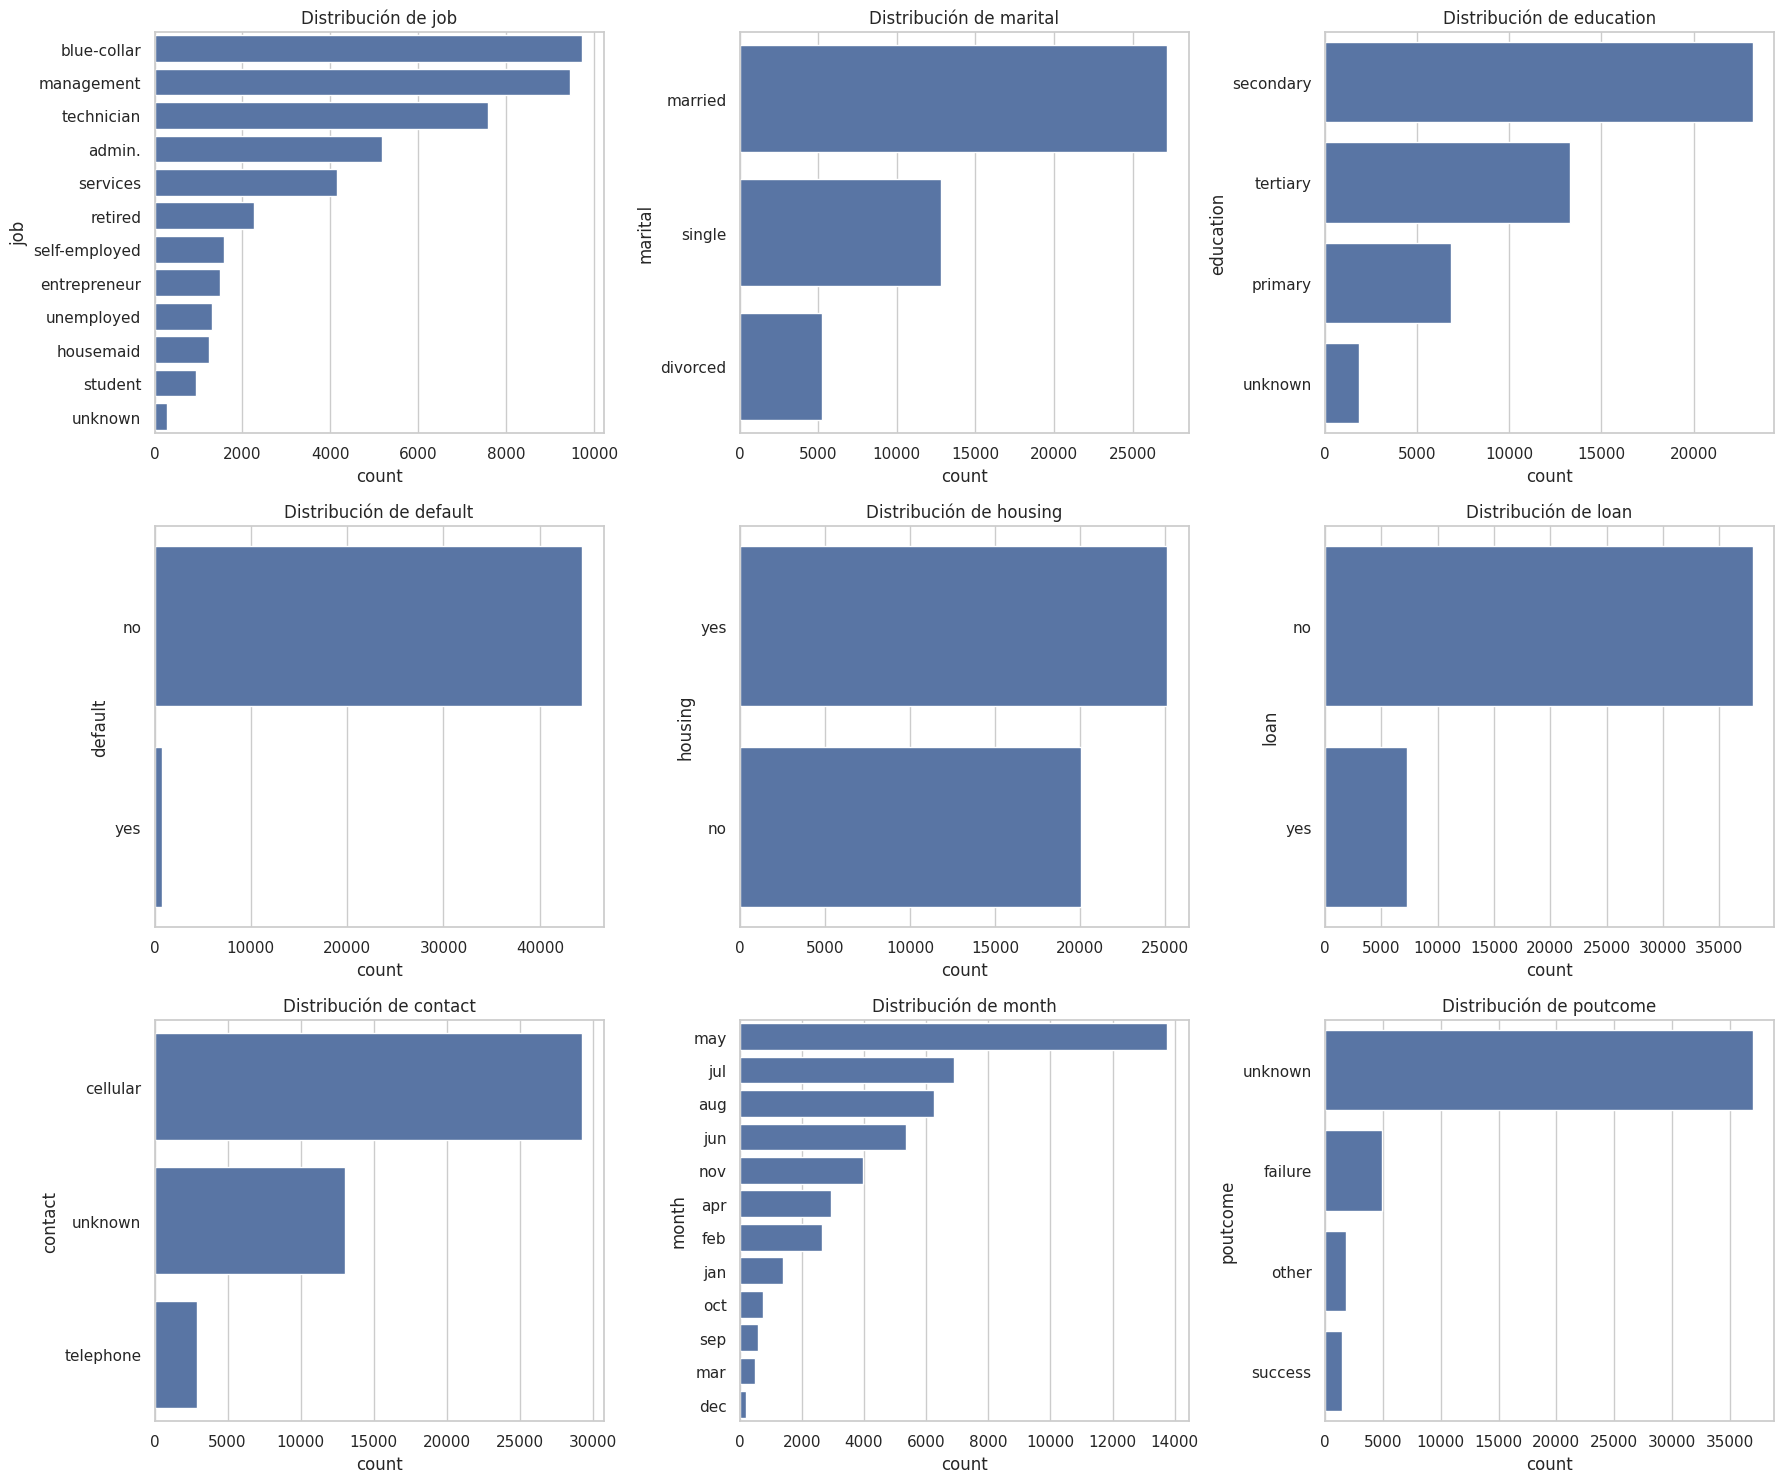

In [22]:
# Visualización de variables categóricas
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()
for i, col in enumerate(cats):
    if i < len(axes):
        sns.countplot(y=col, data=df, ax=axes[i], order=df[col].value_counts().index)
        axes[i].set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

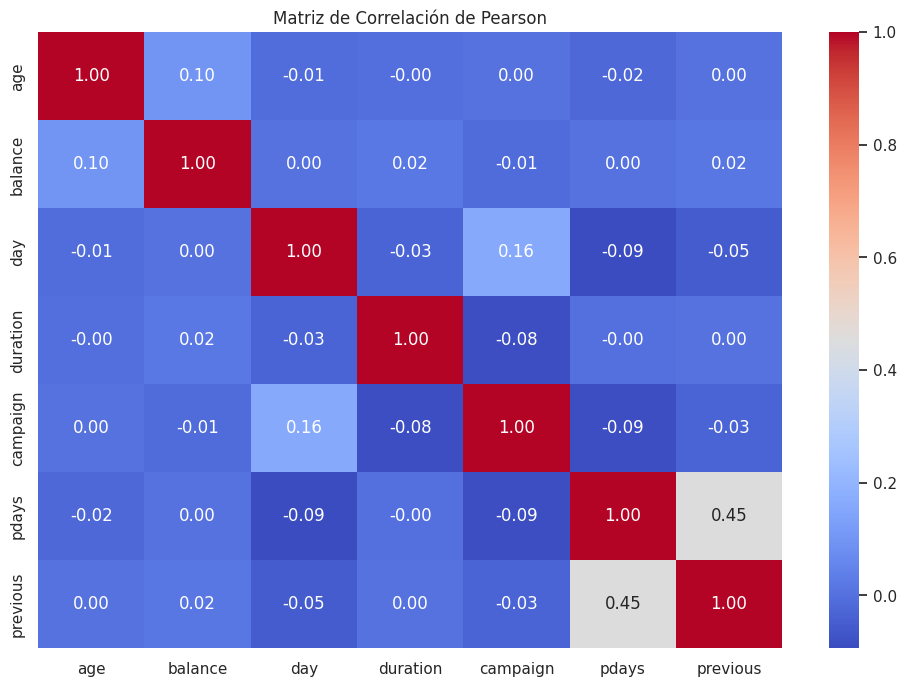

In [6]:
# 5. ANÁLISIS DE CORRELACIONES Y DEPENDENCIAS (Joint Distributions)
# Importante para que el modelo sintético no genere combinaciones imposibles
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Pearson")
plt.show()

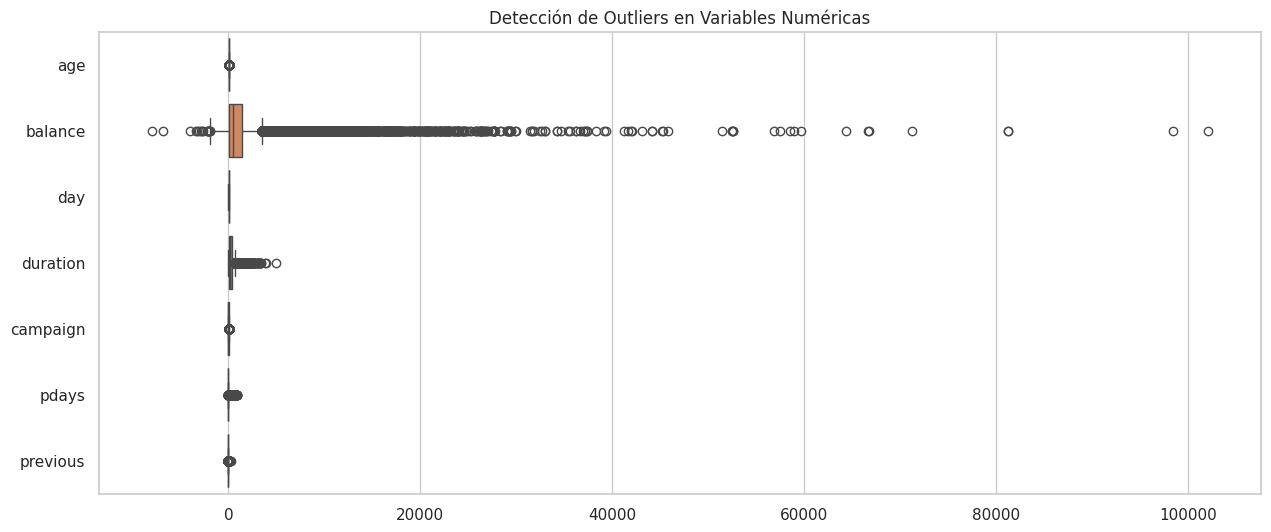

Distribución de la variable objetivo 'y':
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


In [7]:

# 6. IDENTIFICACIÓN DE OUTLIERS
# Los modelos generativos suelen tener problemas con las colas largas (heavy tails)
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[nums], orient="h")
plt.title("Detección de Outliers en Variables Numéricas")
plt.show()

# 7. CHEQUEO DE BALANCE DE CLASES (Target Variable)
print("Distribución de la variable objetivo 'y':")
print(df['y'].value_counts(normalize=True))

In [8]:
from scipy.stats import skew, kurtosis

# Calculando métricas de forma para variables numéricas
shape_metrics = pd.DataFrame({
    'Skewness': df[nums].apply(lambda x: skew(x.dropna())),
    'Kurtosis': df[nums].apply(lambda x: kurtosis(x.dropna()))
})
display(shape_metrics)

,Skewness,Kurtosis
age,0.684795,0.319402
balance,8.360031,140.735848
day,0.093076,-1.059913
duration,3.144214,18.151775
campaign,4.898488,39.245178
pdays,2.615629,6.934296
previous,41.845066,4506.362118


In [9]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Preparación rápida para MI
df_encoded = df.apply(LabelEncoder().fit_transform)
mi_scores = mutual_info_classif(df_encoded.drop('balance', axis=1), df_encoded['balance'])

mi_df = pd.Series(mi_scores, index=df_encoded.columns.drop('balance')).sort_values(ascending=False)
print("Poder predictivo/dependencia respecto a 'balance':")
display(mi_df)

Poder predictivo/dependencia respecto a 'balance':


poutcome     1.022870
marital      0.829497
education    0.630936
housing      0.566821
job          0.414573
age          0.246569
month        0.114044
contact      0.090288
campaign     0.084120
loan         0.068393
y            0.058773
day          0.037013
default      0.022121
pdays        0.009859
duration     0.007781
previous     0.000525
dtype: float64

In [10]:
from scipy.stats import entropy

entropy_vals = df[cats].apply(lambda x: entropy(x.value_counts(normalize=True)))
display(entropy_vals.sort_values(ascending=False))

# Probabilidad de éxito (y='yes') por mes
prop_success = df[df['y'] == 'yes']['month'].value_counts(normalize=True)
prop_total = df['month'].value_counts(normalize=True)

diff = (prop_success - prop_total).sort_values()
# Esto te dice en qué meses la probabilidad de éxito se desvía de la media

job          2.117809
month        2.036037
education    1.119365
marital      0.911676
contact      0.816198
housing      0.686898
poutcome     0.649489
loan         0.440045
y            0.360874
default      0.090256
dtype: float64

In [28]:
from scipy.stats import ks_2samp

def analyze_conditional_necessity(dataframe, target_col, numerical_columns):
    """
    Aplica la prueba K-S de dos muestras para evaluar si las variables numéricas
    se distribuyen de forma diferente según las categorías del target.
    """
    classes = dataframe[target_col].unique()
    if len(classes) != 2:
        raise ValueError("Esta función simplificada está diseñada para un target binario.")
        
    df_class_0 = dataframe[dataframe[target_col] == classes[0]]
    df_class_1 = dataframe[dataframe[target_col] == classes[1]]
    
    results = []
    for col in numerical_columns:
        # Prueba K-S entre las dos distribuciones
        stat, p_value = ks_2samp(df_class_0[col], df_class_1[col])
        results.append({
            'Variable': col,
            'Estadístico K-S': round(stat, 4),
            'P-Valor': round(p_value, 6),
            '¿Requiere atención condicional? (p < 0.05)': p_value < 0.05
        })
        
    return pd.DataFrame(results)

# 1. Definir columnas numéricas de interés
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# 2. Ejecutar el análisis respecto a la columna objetivo 'y'
ks_report = analyze_conditional_necessity(df, 'y', numerical_cols)
display(ks_report.sort_values(by='Estadístico K-S', ascending=False))

,Variable,Estadístico K-S,P-Valor,¿Requiere atención condicional? (p < 0.05)
3,duration,0.4445,0.0,True
5,pdays,0.2016,0.0,True
6,previous,0.2011,0.0,True
1,balance,0.1291,0.0,True
4,campaign,0.1089,0.0,True
0,age,0.0838,0.0,True
2,day,0.0658,0.0,True
